<a href="https://colab.research.google.com/github/Vishalkumar800/Titanic-Dataset-Cleaning-and-EDA-/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("train.csv")

## Titanic data EDA

In [3]:
data_df = data.copy()
data_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## Information about Titanic Data

`PClass` Passenger kis class me beta tha 1 class 2 class or 3 class

`SibSp` Siblings + Spouses
   
   `***`Yaani passenger ke saath Titanic par kitne siblings (bhai/behen) ya spouse (husband/wife) travel kar rahe the.

  
  `Parch` Parents + Children.

  `Fare` price kya diya hai

  `Cabin` kis cabin me beta hai

  `Embarked`  You can call station name
  | Code | Port        |
 | ----  | ----------- |
| `C`   | Cherbourg   |
| `Q`   | Queenstown  |
| `S`   | Southampton |




`Numerical` :  PassengerId , Age , Fare

`Categorical` Survived , PClass ,  Sex ,Parch ,  SibSp , Embarked.

`Mixed` : Name , Ticket  , Cabin ,

In [4]:
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## Univariate :
 Jb aap ek single column ke upr analysis krte ho toh usse univariate bola jata hai .

## Bivariate :
Jb aap 2 columns ka sath me analysis krte ho toh usse `Bivariate` bola jata hai

## MultiVariate :
Jb aap more than 2 column ka analysis ek sath krte ho tab usse `Multivariate` bola jata hai.

### *** Ek sb step krne ke baad aap fhir `Feature engineering` kroge ****

`Feature engineering :` Existing data ko transform krke new useful column banane ko feature engineering bolte hai


yani tum simple def bol skhte ho : new column banane ko feature engineering bolte hai.

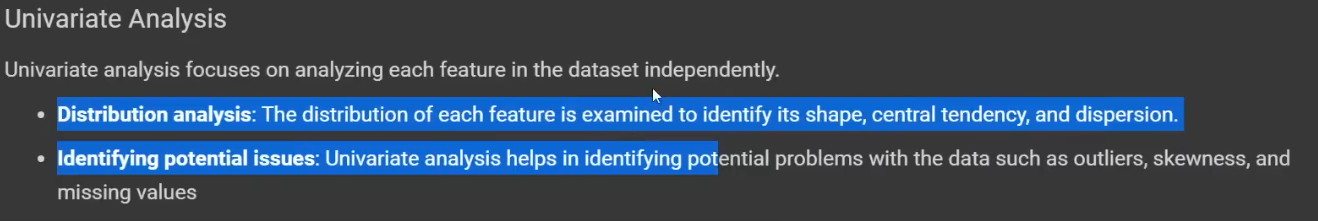

`Central Tendency : `
   
    Mean , Median , Mode

`Dispersion :`

     Range ,  Standard , Variance ,  IQR (Interquartile Range )

 ### IQR (  InterQuatile Range )  

In [5]:
x=  [0,1,20,21,22,23,24,25,30,90,100]

np.percentile(x , [25,75])

array([20.5, 27.5])

In [6]:
IQR = 27.5 - 20.5
IQR

7.0

In [7]:
iqr_min = 20.5 - (1.5 * 7)
iqr_max = 27.5 + (1.5 * 7)

ans = [iqr_min , iqr_max]
ans

[10.0, 38.0]

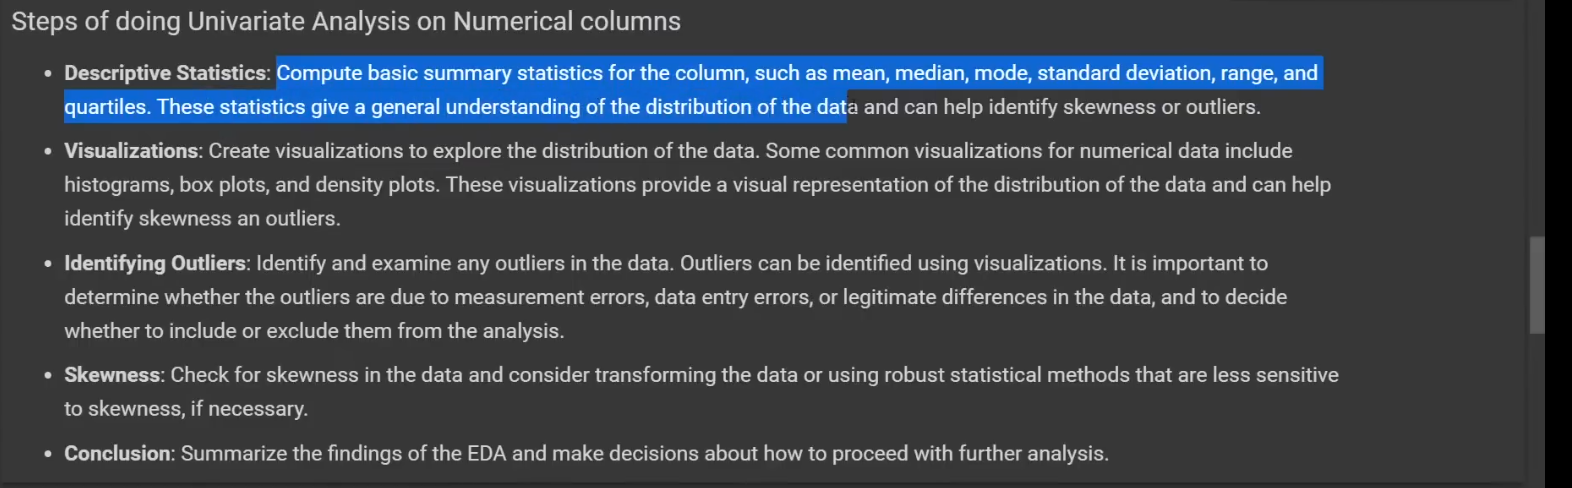

## Steps of doing Univariate analysis on Categorical columns

1. `Descriptive Statistics` Compute the frequency distribution of the categorical column. This will give a general understanding of the distribution of the categories and theri relative frequencies .

simple mtlab of `Frequency distribution` ki uske andr kitne category hai like in Gender column male kitne hai and female.

2. `Visualizations :` Esme aap `** count plots and pie charts *** `ke throw dekhte ho and analysis krte ho category ki . These visualization provide a visual representation of the distribution of the categories and can help indentify any patterns or anomalies in the data.



In [8]:
data_df["Age"].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


## Problems in
`Age`

1. Age me PassengerId = 804 wale bnde ki 0.42 hai

2. Age is normally distributed

3. Age me 20% value is empty

`Fair`

1. The data is highly (positively ) skewed.

2. Fare col actually contains the group fare and not the individual fare .(This might be and issue )

3. We need to create a new column called individual fare.


`Cabin`

1. 687 missing values

`Embarked`

1. 2 missing values

## Parch and SibSp col can be merged to form a new col called family_size

`You can also create a new col called  IsAlone`


In [9]:
data_df[data_df["Age"] == 0.420000]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C


<Axes: xlabel='Age', ylabel='Count'>

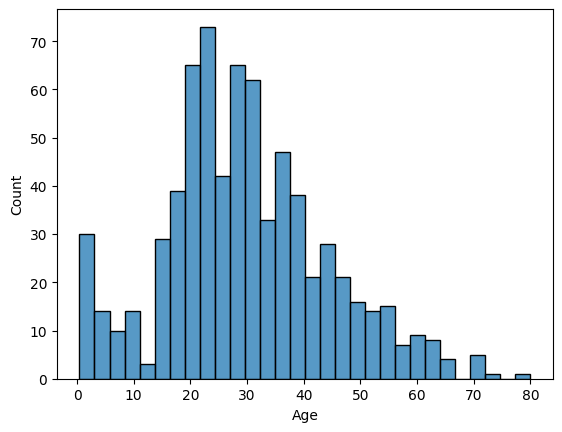

In [10]:
sns.histplot(data= data_df["Age"],bins=30)

<Axes: xlabel='Age', ylabel='Density'>

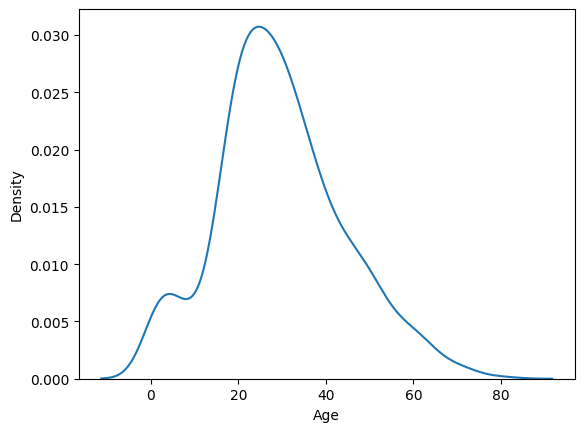

In [11]:
sns.kdeplot(data=data_df["Age"])

In [12]:
data_df["Age"].skew() # agr skew ki value 0 ke aas pass hai toh shi hai data normally distributed hai but yhi

# agr positive hai toh graph positive side hai agr neg toh negative side

np.float64(0.38910778230082704)

In [13]:
data_df['Fare'].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


In [14]:
data_df[data_df['Fare'] > 250]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


In [15]:
data_df[data_df.duplicated(subset=['Ticket'])]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
24,25,0,3,"Palsson, Miss. Torborg Danira",female,8.0,3,1,349909,21.0750,NaN,S
71,72,0,3,"Goodwin, Miss. Lillian Amy",female,16.0,5,2,CA 2144,46.9000,NaN,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
117,118,0,2,"Turpin, Mr. William John Robert",male,29.0,1,0,11668,21.0000,NaN,S
119,120,0,3,"Andersson, Miss. Ellis Anna Maria",female,2.0,4,2,347082,31.2750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
876,877,0,3,"Gustafsson, Mr. Alfred Ossian",male,20.0,0,0,7534,9.8458,NaN,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q


In [16]:
data_df['Survived'].value_counts()

,count
Survived,
0,549
1,342


([<matplotlib.patches.Wedge at 0x7c78756b1400>,
 [Text(-0.39257494735793463, 1.0275626067091557, 'Not Survived'),
  Text(0.3925749146953058, -1.0275626191877425, 'Survived')],
 [Text(-0.21413178946796432, 0.5604886945686304, '61.6%'),
  Text(0.21413177165198496, -0.5604887013751322, '38.4%')])

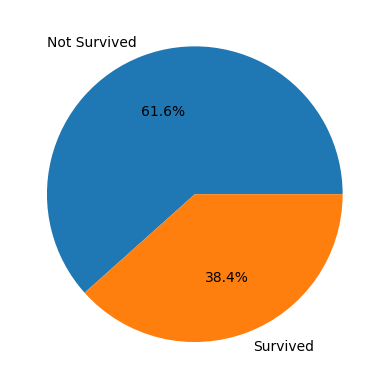

In [17]:
plt.pie(data_df['Survived'].value_counts(),labels=['Not Survived','Survived'] , autopct='%0.1f%%')

In [18]:
data_df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


([<matplotlib.patches.Wedge at 0x7c7873515310>,
 [Text(-0.17571619097547903, 1.085874679799225, '3rd Class'),
  Text(-0.5160760536623383, -0.9714244730478574, '1st Class'),
  Text(0.8765111790709129, -0.6646263258130227, '2nd Class')],
 [Text(-0.09584519507753402, 0.5922952798904862, '55.1%'),
  Text(-0.2814960292703663, -0.5298678943897404, '24.2%'),
  Text(0.47809700676595246, -0.3625234504434669, '20.7%')])

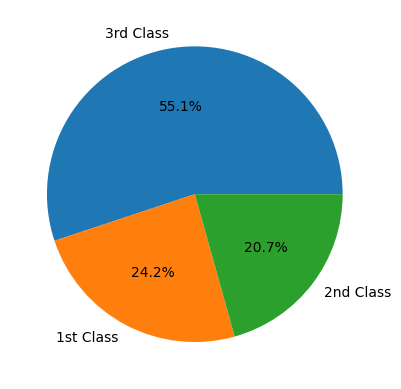

In [19]:
plt.pie(data_df['Pclass'].value_counts() , labels=['3rd Class' , '1st Class' , '2nd Class'] , autopct='%0.1f%%')

In [20]:
data_df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [21]:
data_df['SibSp'].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


<Axes: xlabel='SibSp', ylabel='count'>

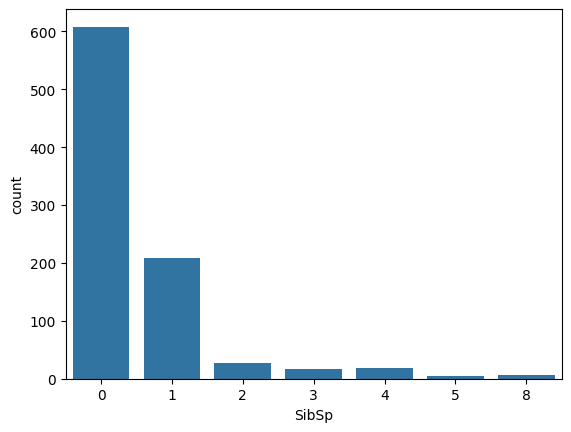

In [22]:
sns.barplot(data_df['SibSp'].value_counts() )

In [23]:
data_df['Parch'].value_counts()

,count
Parch,
0,678
1,118
2,80
5,5
3,5
4,4
6,1


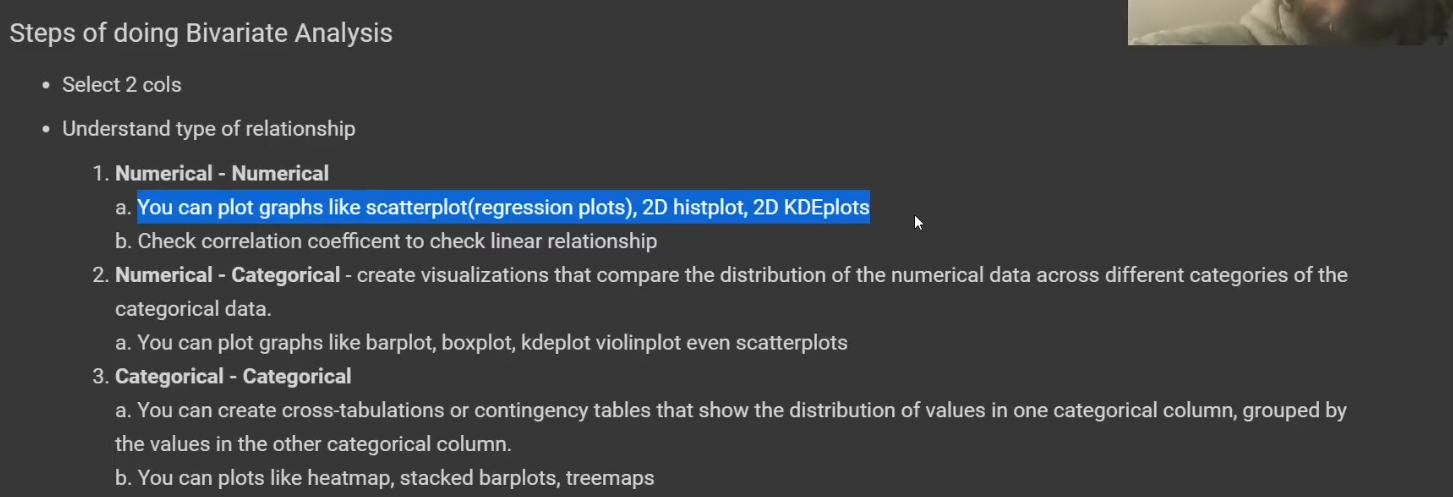

Survived And PClass are both categorial

In [24]:
pd.crosstab(data_df["Survived"] , data_df["Pclass"] , normalize='columns')*100

Pclass,1,2,3
Survived,,,
0,37.037037,52.717391,75.763747
1,62.962963,47.282609,24.236253


# 📊 Pandas Crosstab — `normalize="columns"`

---

## 🔹 What is `pd.crosstab()`?

`pd.crosstab()` ka use do ya do se zyada categorical variables ke beech **frequency/count relationship** dekhne ke liye hota hai.

### Example:

```python
pd.crosstab(
    data_df["Survived"],
    data_df["Pclass"]
)
```

Output:

| Survived | Pclass 1 | Pclass 2 | Pclass 3 |
|:--------:|---------:|---------:|---------:|
| 0 | 80 | 97 | 372 |
| 1 | 136 | 87 | 119 |

### Meaning:

- `0` → Not Survived
- `1` → Survived
- `Pclass 1` → First Class
- `Pclass 2` → Second Class
- `Pclass 3` → Third Class

---

# 🔥 `normalize="columns"`

Agar hum `normalize="columns"` use karte hain:

```python
pd.crosstab(
    data_df["Survived"],
    data_df["Pclass"],
    normalize="columns"
)
```

Toh Pandas **har column ko independently normalize** karta hai.

### Simple Meaning:

> **Har Pclass ke andar Survived aur Not Survived passengers ka percentage calculate karna.**

---

# 🧮 How Does It Work?

## 🟢 Pclass 1

Normal crosstab:

| Survived | Count |
|:--------:|------:|
| 0 | 80 |
| 1 | 136 |

### Step 1 — Total passengers

```text
80 + 136 = 216
```

### Step 2 — Not Survived percentage

```text
80 / 216 × 100 = 37.04%
```

### Step 3 — Survived percentage

```text
136 / 216 × 100 = 62.96%
```

Therefore:

```text
37.04% + 62.96% = 100%
```

---

## 🟡 Pclass 2

Normal crosstab:

| Survived | Count |
|:--------:|------:|
| 0 | 97 |
| 1 | 87 |

### Total passengers

```text
97 + 87 = 184
```

### Not Survived

```text
97 / 184 × 100 = 52.72%
```

### Survived

```text
87 / 184 × 100 = 47.28%
```

Therefore:

```text
52.72% + 47.28% = 100%
```

---

## 🔴 Pclass 3

Normal crosstab:

| Survived | Count |
|:--------:|------:|
| 0 | 372 |
| 1 | 119 |

### Total passengers

```text
372 + 119 = 491
```

### Not Survived

```text
372 / 491 × 100 = 75.76%
```

### Survived

```text
119 / 491 × 100 = 24.24%
```

Therefore:

```text
75.76% + 24.24% = 100%
```

---

# 📋 Final Result

```python
pd.crosstab(
    data_df["Survived"],
    data_df["Pclass"],
    normalize="columns"
) * 100
```

Output:

| Survived | Pclass 1 | Pclass 2 | Pclass 3 |
|:--------:|---------:|---------:|---------:|
| 0 | 37.04% | 52.72% | 75.76% |
| 1 | 62.96% | 47.28% | 24.24% |

---

# 🔍 How to Read This Table?

### Pclass 1

- `62.96%` passengers survived.
- `37.04%` passengers did not survive.

### Pclass 2

- `47.28%` passengers survived.
- `52.72%` passengers did not survive.

### Pclass 3

- `24.24%` passengers survived.
- `75.76%` passengers did not survive.

---

# 🔹 Why Do We Use `* 100`?

Without `* 100`:

```python
pd.crosstab(
    data_df["Survived"],
    data_df["Pclass"],
    normalize="columns"
)
```

Output decimal form mein aayega:

| Survived | Pclass 1 | Pclass 2 | Pclass 3 |
|:--------:|---------:|---------:|---------:|
| 0 | 0.3704 | 0.5272 | 0.7576 |
| 1 | 0.6296 | 0.4728 | 0.2424 |

`* 100` decimal ko percentage mein convert karta hai.

### Example:

```text
0.6296 × 100 = 62.96%
```

---

# 🧠 Important Concept

### `normalize="columns"`

> **Har column ka total 100% kar deta hai.**

For example:

```text
Pclass 1:
37.04% + 62.96% = 100%

Pclass 2:
52.72% + 47.28% = 100%

Pclass 3:
75.76% + 24.24% = 100%
```

---

# ⭐ One-Line Definition

> **`normalize="columns"` means each column is normalized independently, so the values within each column represent percentages and add up to 100%.**

### Titanic Example:

> **It tells us what percentage of passengers in each Pclass survived and what percentage did not survive.**

In [25]:
pd.crosstab(data_df["Survived"] , data_df["Sex"], normalize='columns' )*100

Sex,female,male
Survived,,
0,25.796178,81.109185
1,74.203822,18.890815


In [26]:
pd.crosstab(data_df["Survived"] , data_df["Embarked"], normalize='columns')*100

Embarked,C,Q,S
Survived,,,
0,44.642857,61.038961,66.304348
1,55.357143,38.961039,33.695652


In [27]:

'''

1. ` Southampton `, England 🇬🇧
➡️ 10 April 1912 ko Titanic yahan se journey par nikli.

2. Cherbourg, France 🇫🇷
➡️ Yahan Titanic stop hui aur passengers/cargo liya.

3. Queenstown (aaj ka Cobh), Ireland 🇮🇪
➡️ Yahan bhi Titanic ruki aur additional passengers/mail liya.

'''

pd.crosstab(data_df['Sex'] , data_df['Embarked'] , normalize = 'columns') * 100 # yeah case volilate kr rha hai kyu male jyada chaade the 3 cities se


Embarked,C,Q,S
Sex,,,
female,43.452381,46.753247,31.521739
male,56.547619,53.246753,68.478261


In [28]:
pd.crosstab(data_df['Pclass'] ,data_df['Embarked'] , normalize = 'columns') * 100

Embarked,C,Q,S
Pclass,,,
1,50.595238,2.597403,19.720497
2,10.119048,3.896104,25.465839
3,39.285714,93.506494,54.813665


In [29]:
# C station wale esliye bch gye kyuki wha se 50 percent 1st class wale the


# Categorical and Numerical

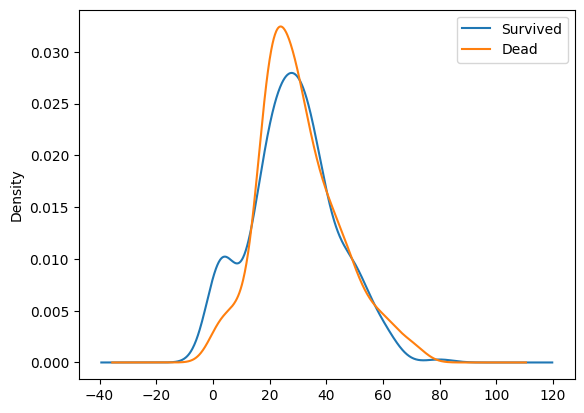

In [30]:
data_df[data_df['Survived'] == 1]['Age'].plot(kind='kde',label = 'Survived')
data_df[data_df['Survived'] == 0]['Age'].plot(kind='kde',label="Dead")

plt.legend()
plt.show()

In [31]:
data_df['SibSp'].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


In [32]:
data_df[data_df['SibSp'] == 8 ]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [33]:
data_df['individual_fare'] = data_df['Fare'] / (data_df['SibSp'] + data_df['Parch'] + 1)

In [34]:
data_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,13.00000
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,30.00000
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,5.86250
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,30.00000


In [35]:
data_df["Family"] = data['SibSp'] + data_df['Parch'] +1


In [36]:
data_df.drop(['SibSp','Parch'],axis=1,inplace=True)

In [37]:
data_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked,individual_fare,Family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,7.2500,NaN,S,3.62500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,71.2833,C85,C,35.64165,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,STON/O2. 3101282,7.9250,NaN,S,7.92500,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,113803,53.1000,C123,S,26.55000,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,373450,8.0500,NaN,S,8.05000,1


In [38]:
def transform_family(num):

  if num == 1:
    return "alone"
  elif num > 1 and num <5 :
    return "small"
  else:
    return "large"



In [39]:
data_df["family_type"] = data_df['Family'].apply(transform_family)


In [40]:
pd.crosstab(data_df['Survived'] , data_df['family_type'],normalize = 'columns') * 100

family_type,alone,large,small
Survived,,,
0,69.646182,83.870968,42.123288
1,30.353818,16.129032,57.876712


In [41]:
nameSplit = data_df['Name'].str.split(',')
data_df['Surname'] = nameSplit.str.get(0)
data_df['NameOnly'] = nameSplit.str.get(1)

In [42]:
data_df['title'] = data_df['NameOnly'].str.split('.').str.get(0)
data_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked,individual_fare,Family,family_type,Surname,NameOnly,title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,7.2500,NaN,S,3.62500,2,small,Braund,Mr. Owen Harris,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,71.2833,C85,C,35.64165,2,small,Cumings,Mrs. John Bradley (Florence Briggs Thayer),Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,STON/O2. 3101282,7.9250,NaN,S,7.92500,1,alone,Heikkinen,Miss. Laina,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,113803,53.1000,C123,S,26.55000,2,small,Futrelle,Mrs. Jacques Heath (Lily May Peel),Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,373450,8.0500,NaN,S,8.05000,1,alone,Allen,Mr. William Henry,Mr


In [43]:
data_df['Cabin'].value_counts().head(15)

,count
Cabin,
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
D,3
E101,3
C22 C26,3
F33,3
C83,2


In [44]:
data_df['Cabin'].fillna("M" , inplace = True)

/tmp/ipykernel_619/2371193346.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_df['Cabin'].fillna("M" , inplace = True)


In [45]:
data_df["deck"] = data_df['Cabin'].str[0]

In [46]:
data_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked,individual_fare,Family,family_type,Surname,NameOnly,title,deck
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,7.2500,M,S,3.62500,2,small,Braund,Mr. Owen Harris,Mr,M
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,71.2833,C85,C,35.64165,2,small,Cumings,Mrs. John Bradley (Florence Briggs Thayer),Mrs,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,STON/O2. 3101282,7.9250,M,S,7.92500,1,alone,Heikkinen,Miss. Laina,Miss,M
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,113803,53.1000,C123,S,26.55000,2,small,Futrelle,Mrs. Jacques Heath (Lily May Peel),Mrs,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,373450,8.0500,M,S,8.05000,1,alone,Allen,Mr. William Henry,Mr,M
